In [1]:
import tensorflow as tf


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

data = pd.read_csv("daily-minimum-temperatures-in-me.csv", parse_dates=["Date"], on_bad_lines='skip')
print(data.head())


        Date Daily minimum temperatures in Melbourne, Australia, 1981-1990
0 1981-01-01                                               20.7           
1 1981-01-02                                               17.9           
2 1981-01-03                                               18.8           
3 1981-01-04                                               14.6           
4 1981-01-05                                               15.8           


In [5]:
data


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [9]:
# Por posición
x = data.iloc[:, [0]].values      # 2D (columna 0)
y = data.iloc[:, 1].values        # 1D  (columna 1)


In [10]:
!head data

'head' is not recognized as an internal or external command,
operable program or batch file.


In [11]:
data

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


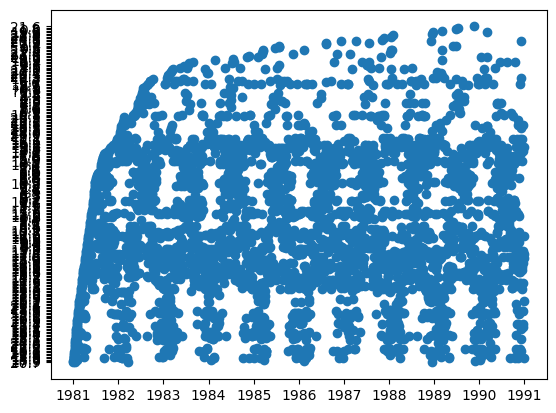

In [13]:
plt.scatter(x, y)

In [21]:
y = pd.to_numeric(y, errors="coerce")  # convierte strings a float, NaN si no puede


C:\Users\MarioSoler\AppData\Local\Temp\ipykernel_26128\3680470514.py:1: RuntimeWarning: invalid value encountered in log
  y = np.log(y)


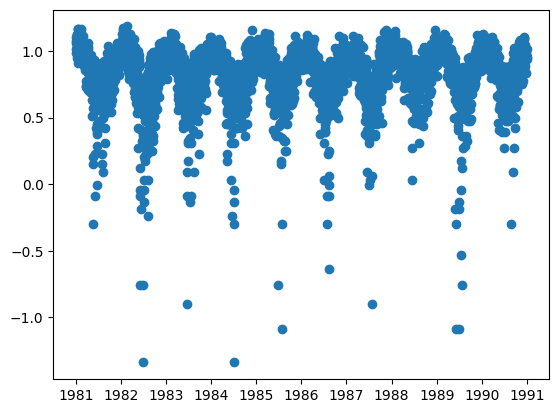

In [23]:
y = np.log(y)
plt.scatter(x, y)

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1) Cargar y normalizar nombres de columnas
df = pd.read_csv(
    "daily-minimum-temperatures-in-me.csv",
    parse_dates=["Date"],
    on_bad_lines="skip",
    engine="python"   # parser más tolerante
)

# Tomar la segunda columna (sea 'Temp' o el texto largo) y renombrarla a 'Temp'
second_col = df.columns[1]
df = df.rename(columns={second_col: "Temp"})
# limpiar posibles espacios/saltos de línea en nombres
df.columns = [str(c).strip() for c in df.columns]

# 2) Limpiar y ordenar
df = df.dropna(subset=["Date", "Temp"]).sort_values("Date")

# 3) Promedio por año
df["Year"] = df["Date"].dt.year
yearly = df.groupby("Year", as_index=False)["Temp"].mean()

# 4) Escalar (opcional)
scaler = StandardScaler()
yearly["Temp_scaled"] = scaler.fit_transform(yearly[["Temp"]])

# 5) Graficar
fig, ax = plt.subplots(figsize=(8,4))
ax.scatter(yearly["Year"], yearly["Temp_scaled"], s=25)
ax.set_xlabel("Año"); ax.set_ylabel("Temp (escalada)")
ax.set_title("Temperatura mínima promedio por año (escalada)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


TypeError: agg function failed [how->mean,dtype->object]